# Optimizers — From SGD to AdamW

How do we actually use the gradients computed by backprop (notebook `03_autograd.ipynb`)
to minimize the loss? An **optimizer** defines the update rule that turns gradients into
parameter changes.

This notebook builds the family of gradient-based optimizers step by step, each one fixing
a weakness of the previous:

| Optimizer | Key idea | Fixes |
|-----------|----------|-------|
| **SGD** | step opposite to the gradient | baseline |
| **+ Momentum** | accumulate a velocity | reduces oscillation, speeds up |
| **Adagrad** | per-parameter adaptive LR | handles sparse / uneven scales |
| **RMSProp** | *moving* average of squared grads | stops Adagrad's LR from vanishing |
| **Adam** | momentum **+** RMSProp + bias correction | robust default |
| **AdamW** | Adam with decoupled weight decay | correct regularization |

We test them on the **Rosenbrock function**, then add **learning-rate scheduling**
(warm-up + cosine annealing).

In [2]:
#In this notebook, we will implment the gradient descent algorithm, the Adam optimization algorithm and the gradient clipping technique.
#libraries
import sys
import os
sys.path.append(os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
from train import Value
%matplotlib inline

#https://medium.com/@jimmywanggenai/comparing-optimizers-in-pytorch-and-tensorflow-d7d8ab87d890
#https://medium.com/@sushmita2310/types-of-optimizers-in-deep-learning-a-comprehensive-guide-af258d6acf66

##### SGD Optimizer

The simplest gradient-based algorithm is **Stochastic Gradient Descent (SGD)**. It updates the parameters of the model in the opposite direction of the gradient of the loss \
function with respect to the parameters. The update rule is given by:
$$\theta = \theta - \alpha \nabla_\theta J(\theta)$$
where $\theta$ are the parameters of the model, $\alpha$ is the learning rate and $J(\theta)$ is the loss function.

minimum value: 0
gradient at (1,1): 0.0 0.0


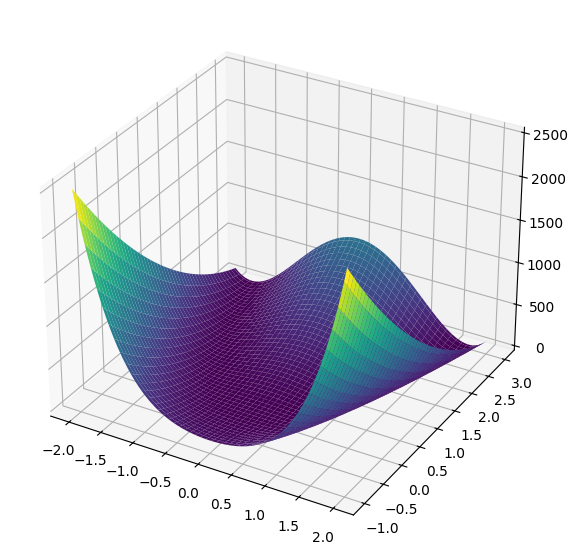

In [3]:
# Define the rosenbrock function to use as a test function for optimization
#f(x, y) = (a - x)^2 + b * (y - x^2)^2, where a = 1 and b = 100
#df/dx = -2 * (a - x) - 4 * b * x * (y - x^2)
#df/dy = 2 * b * (y - x^2)
def rosenbrock(x: Value, y: Value) -> Value:
    return (1 - x) ** 2 + 100 * (y - x ** 2) ** 2

#Gradient at (1,1) should be (0,0)
x = Value(1, label='x')
y = Value(1, label='y')
print("minimum value:", rosenbrock(x, y))
f = rosenbrock(x, y)
f.grad = 1.0
f.backward()
print("gradient at (1,1):", x.grad, y.grad)

#Lets plot the rosenbrock function in 3D
x = np.linspace(-2, 2, 100)
y = np.linspace(-1, 3, 100)
X, Y = np.meshgrid(x, y)
Z = (1 - X) ** 2 + 100 * (Y - X ** 2) ** 2
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')

In [5]:
# training loop function to be used in the optimization algorithms
def train(model, parameters, learning_rate=0.01, max_iters=10000, tol=0.01, target = (1,1), optimizer=None, lr_schedule=None):
    print("i \t f \t x.data \t y.data \t x.grad \t y.grad")
    for i in range(max_iters):
        f = model(parameters)
        f.zero_grad()
        f.grad = 1.0
        f.backward()
        if lr_schedule is not None:
            learning_rate = lr_schedule(i)
        optimizer(parameters, learning_rate=learning_rate)
        if abs(x.data -target[0]) < tol and abs(y.data - target[1]) < tol:
            return i
        if i % 500 == 0:
            print(f"{i} \t {f.data:.2f} \t {x.data:.2f} \t {y.data:.2f} \t {x.grad:.2f} \t {y.grad:.2f}")
    return max_iters

In [6]:
#SGD Optimizer
#The Stochastic Gradient Descent (SGD) optimizer is a simple optimization algorithm that 
# updates the parameters of a model in the opposite direction of the gradient of the loss 
# function with respect to the parameters. The learning rate determines the step size of the update.
def sgd(parameters, learning_rate=0.01):
    for p in parameters:
        p.data -= learning_rate * p.grad

#Lest test the SGD optimizer on the rosenbrock function
x = Value(-1.5, label='x')
y = Value(1.5, label='y')
parameters = [x, y]
true_xy = (1, 1)
def model(parameters):
    x, y = parameters
    return rosenbrock(x, y)

print("Training with SGD optimizer:")
max_iters = 10000
lr_rate = 0.002
n_iter = train(model, parameters, learning_rate=lr_rate, max_iters=max_iters, tol=0.01, optimizer=sgd, target=true_xy)
print("===================================================================")
print(f"Iterations to converge: {n_iter}/{max_iters}; Learning Rate: {lr_rate}")
print("Minimum value:", f, "at (", x, ",", y, ")")
print("Gradient at minimum:", x.grad, y.grad)

Training with SGD optimizer:
i 	 f 	 x.data 	 y.data 	 x.grad 	 y.grad
0 	 62.50 	 -0.59 	 1.80 	 -455.00 	 -150.00
500 	 0.38 	 0.38 	 0.14 	 -0.78 	 -0.60
1000 	 0.07 	 0.73 	 0.53 	 -0.17 	 -0.25
1500 	 0.02 	 0.85 	 0.72 	 -0.08 	 -0.13
2000 	 0.01 	 0.91 	 0.82 	 -0.04 	 -0.08
2500 	 0.00 	 0.94 	 0.88 	 -0.03 	 -0.05
3000 	 0.00 	 0.96 	 0.92 	 -0.02 	 -0.03
3500 	 0.00 	 0.97 	 0.95 	 -0.01 	 -0.02
4000 	 0.00 	 0.98 	 0.97 	 -0.01 	 -0.01
4500 	 0.00 	 0.99 	 0.98 	 -0.00 	 -0.01
5000 	 0.00 	 0.99 	 0.99 	 -0.00 	 -0.01
Iterations to converge: 5493/10000; Learning Rate: 0.002
Minimum value: 0 at ( 0.9950009317354853 , 0.9900067896495147 )
Gradient at minimum: -0.002014090677535701 -0.004016144264196164


##### SGD with Momentum 
The SGD with momentum optimizer is an extension of the SGD optimizer that adds a momentum term to the update.\
The momentum term helps to accelerate the convergence of the optimization reducing the oscillation by adding \
a fraction of the previous update to the current update. The update rule for SGD with momentum is:
$$v = \beta v - \alpha \nabla_\theta J(\theta)$$
$$\theta = \theta + v$$
where $\theta$ are the parameters, $\alpha$ is the learning rate, $\beta$ is the momentum hyperparameter, $v$ is the velocity, and $J(\theta)$ is the loss function.

In [7]:
#SGD with momentum optimizer
#The momemtum comes from the exponential weighted average of the gradients,
#  which helps to accelerate the convergence and avoid local minima. 
# The momentum term is added to the update rule of the parameters,
#  which allows the optimizer to maintain a velocity that can help it to escape from local minima and converge faster.

def sgd_momentum(parameters, learning_rate=0.01, momentum=0.9):
    for p in parameters:
        #initialize velocity if it does not exist
        if not hasattr(p, 'velocity'):
            p.velocity = 0
        #v = momentum * v - learning_rate * p.grad 
        p.velocity = momentum * p.velocity - learning_rate * p.grad
        #p.data += v
        p.data += p.velocity

#Lets test the SGD with momentum optimizer on the rosenbrock function
x = Value(-1.5, label='x')
y = Value(1.5, label='y')
parameters = [x, y]
true_xy = (1, 1)
def model(parameters):
    x, y = parameters
    return rosenbrock(x, y)

print("Training with SGD with momentum optimizer:")
max_iters = 10000
lr_rate = 0.002
n_iter = train(model, parameters, learning_rate=lr_rate, max_iters=max_iters, tol=0.01, optimizer=sgd_momentum, target=true_xy)
print("===================================================================")
print(f"Iterations to converge: {n_iter}/{max_iters}; Learning Rate: {lr_rate}")
print("Minimum value:", f, "at (", x, ",", y, ")")
print("Gradient at minimum:", x.grad, y.grad)

Training with SGD with momentum optimizer:
i 	 f 	 x.data 	 y.data 	 x.grad 	 y.grad
0 	 62.50 	 -0.59 	 1.80 	 -455.00 	 -150.00
500 	 0.00 	 0.99 	 0.99 	 -0.00 	 -0.00
Iterations to converge: 515/10000; Learning Rate: 0.002
Minimum value: 0 at ( 0.9950238970328104 , 0.9900525817926308 )
Gradient at minimum: -0.002020227263306147 -0.004030148456091176


##### Adagrad optimizer
The Adagrad optimizer is an adaptive learning rate optimization algorithm that adjusts the learning rate \
for each parameter based on the historical gradients. It maintains a sum of the squares of the gradients \
for each parameter and uses this information to scale the learning rate for each parameter. \
This allows the optimizer to adapt to the geometry of the loss function and can lead to faster convergence, \
especially for sparse data. The definition of the Adagrad optimizer is as follows:
$$\theta = \theta - \frac{\alpha}{\sqrt{G_t + \epsilon}} \nabla_\theta J(\theta)$$
where $G_t$ is the sum of the squares of the gradients up to time step $t$ and $\epsilon$ is a small constant to prevent division by zero.\
$G_t$ is updated as follows:
$$G_t = G_{t-1} + \nabla_\theta J(\theta)^2$$

In [8]:
#Adagrad optimizer
def adagrad(parameters, learning_rate=0.01):
    epsilon = 1e-8
    for p in parameters:
        #initialize sum of squares of gradients if it does not exist
        if not hasattr(p, 'grad_squared'):
            p.grad_squared = 0
        #update sum of squares of gradients
        p.grad_squared += p.grad ** 2
        #update parameters
        p.data -= learning_rate * p.grad / (np.sqrt(p.grad_squared) + epsilon)

#Lets test the Adagrad optimizer on the rosenbrock function
x = Value(-1.5, label='x')
y = Value(1.5, label='y')
parameters = [x, y]
true_xy = (1, 1)
def model(parameters):
    x, y = parameters
    return rosenbrock(x, y)

print("Training with Adagrad optimizer:")
max_iters = 100000
#start with higher learning rate for Adagrad since it adapts the learning rate based on the gradients
lr_rate = 0.1
n_iter = train(model, parameters, learning_rate=lr_rate, max_iters=max_iters, tol=0.01, optimizer=adagrad, target=true_xy)
print("===================================================================")
print(f"Iterations to converge: {n_iter}/{max_iters}; Learning Rate: {lr_rate}")
print("Minimum value:", f, "at (", x, ",", y, ")")
print("Gradient at minimum:", x.grad, y.grad)

Training with Adagrad optimizer:
i 	 f 	 x.data 	 y.data 	 x.grad 	 y.grad
0 	 62.50 	 -1.40 	 1.60 	 -455.00 	 -150.00
500 	 4.68 	 -1.16 	 1.36 	 -1.53 	 1.20
1000 	 4.04 	 -1.01 	 1.02 	 -1.68 	 1.16
1500 	 3.39 	 -0.84 	 0.71 	 -1.87 	 1.08
2000 	 2.73 	 -0.65 	 0.43 	 -2.08 	 0.94
2500 	 2.09 	 -0.44 	 0.20 	 -2.27 	 0.70
3000 	 1.51 	 -0.23 	 0.05 	 -2.29 	 0.36
3500 	 1.04 	 -0.02 	 0.00 	 -2.04 	 0.04
4000 	 0.72 	 0.15 	 0.02 	 -1.65 	 -0.17
4500 	 0.51 	 0.29 	 0.08 	 -1.28 	 -0.25
5000 	 0.37 	 0.39 	 0.15 	 -1.00 	 -0.27
5500 	 0.27 	 0.48 	 0.23 	 -0.80 	 -0.26
6000 	 0.21 	 0.54 	 0.30 	 -0.65 	 -0.24
6500 	 0.16 	 0.60 	 0.36 	 -0.54 	 -0.22
7000 	 0.13 	 0.65 	 0.42 	 -0.45 	 -0.20
7500 	 0.10 	 0.68 	 0.47 	 -0.39 	 -0.18
8000 	 0.08 	 0.72 	 0.51 	 -0.33 	 -0.16
8500 	 0.06 	 0.75 	 0.56 	 -0.29 	 -0.15
9000 	 0.05 	 0.77 	 0.59 	 -0.25 	 -0.13
9500 	 0.04 	 0.79 	 0.63 	 -0.22 	 -0.12
10000 	 0.04 	 0.81 	 0.66 	 -0.20 	 -0.11
10500 	 0.03 	 0.83 	 0.69 	 -0.17 	 -0.

##### RMSProp optimizer
The RMSProp optimizer is an extension of the Adagrad optimizer that addresses the issue of the learning rate decreasing too much over time.\
It does this by introducing a decay factor that allows the optimizer to maintain a moving average of the squared gradients, which helps to \
prevent the learning rate from decreasing too much and allows the optimizer to continue making progress even when the gradients are small.\
The update rule for RMSProp is:
$$\theta = \theta - \frac{\alpha}{\sqrt{E[g^2]_t + \epsilon}} \nabla_\theta J(\theta)$$
$$g = \nabla_\theta J(\theta)$$
where $E[g^2]_t$ is the moving average of the squared gradients, and $\epsilon$ is a small constant to prevent division by zero.\
The moving average of the squared gradients is updated as follows:
$$E[g^2]_t = \beta E[g^2]_{t-1} + (1 - \beta) g^2$$

In [9]:
#RMSProp optimizer
def rmsprop(parameters, learning_rate=0.01, beta=0.9):
    epsilon = 1e-8
    for p in parameters:
        #initialize moving average of squared gradients if it does not exist
        if not hasattr(p, 'grad_squared_avg'):
            p.grad_squared_avg = 0
        #update moving average of squared gradients
        p.grad_squared_avg = beta * p.grad_squared_avg + (1 - beta) * p.grad ** 2
        #update parameters
        p.data -= learning_rate * p.grad / (np.sqrt(p.grad_squared_avg) + epsilon)

#Lets test the RMSProp optimizer on the rosenbrock function
x = Value(-1.5, label='x')
y = Value(1.5, label='y')
parameters = [x, y]
true_xy = (1, 1)
def model(parameters):
    x, y = parameters
    return rosenbrock(x, y)

print("Training with RMSProp optimizer:")
max_iters = 100000
lr_rate = 0.01
n_iter = train(model, parameters, learning_rate=lr_rate, max_iters=max_iters, tol=0.01, optimizer=rmsprop, target=true_xy)
print("===================================================================")
print(f"Iterations to converge: {n_iter}/{max_iters}; Learning Rate: {lr_rate}")
print("Minimum value:", f, "at (", x, ",", y, ")")
print("Gradient at minimum:", x.grad, y.grad)

Training with RMSProp optimizer:
i 	 f 	 x.data 	 y.data 	 x.grad 	 y.grad
0 	 62.50 	 -1.47 	 1.53 	 -455.00 	 -150.00
500 	 0.23 	 0.53 	 0.28 	 1.77 	 -2.54
1000 	 0.04 	 0.83 	 0.70 	 4.38 	 -2.79
1500 	 0.03 	 0.91 	 0.84 	 5.12 	 -2.88
2000 	 0.02 	 0.94 	 0.90 	 5.46 	 -2.92
2500 	 0.02 	 0.96 	 0.93 	 5.64 	 -2.94
3000 	 0.02 	 0.97 	 0.95 	 5.73 	 -2.95
3500 	 0.02 	 0.97 	 0.96 	 5.79 	 -2.96
4000 	 0.02 	 0.98 	 0.97 	 5.82 	 -2.97
4500 	 0.02 	 0.98 	 0.97 	 5.84 	 -2.97
5000 	 0.02 	 0.98 	 0.97 	 5.85 	 -2.97
5500 	 0.02 	 0.98 	 0.97 	 5.85 	 -2.97
6000 	 0.02 	 0.98 	 0.97 	 5.86 	 -2.97
6500 	 0.02 	 0.98 	 0.98 	 5.86 	 -2.97
7000 	 0.02 	 0.98 	 0.98 	 5.86 	 -2.97
7500 	 0.02 	 0.98 	 0.98 	 5.86 	 -2.97
8000 	 0.02 	 0.98 	 0.98 	 5.86 	 -2.97
8500 	 0.02 	 0.98 	 0.98 	 5.86 	 -2.97
9000 	 0.02 	 0.98 	 0.98 	 5.86 	 -2.97
9500 	 0.02 	 0.98 	 0.98 	 5.86 	 -2.97
10000 	 0.02 	 0.98 	 0.98 	 5.86 	 -2.97
10500 	 0.02 	 0.98 	 0.98 	 5.86 	 -2.97
11000 	 0.02 	 0.9

#### Adam optimizer
The Adam optimizer is an optimization algorithm that combines the benefits of both the Momentum and RMSProp optimizers.\
It maintains a moving average of both the gradients and the squared gradients, which allows it to adapt the learning rate \
for each parameter based on the history of gradients.Here is the definition of the Adam optimizer:
$$\begin{aligned}
g_t & = \nabla_\theta J(\theta) \\
m_t &= \beta_1 m_{t-1} + (1 - \beta_1) g_t \\
v_t &= \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \\
\hat{m}_t &= \frac{m_t}{1 - \beta_1^t} \\
\hat{v}_t &= \frac{v_t}{1 - \beta_2^t} \\
\theta &= \theta - \frac{\alpha}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t
\end{aligned}$$
Where:
- $\theta$ is the parameter being optimized.
- $\alpha$ is the learning rate.
- $g_t$ is the gradient of the loss function with respect to $\theta$ at time step $t$.
- $m_t$ is the first moment estimate (the moving average of the gradients).
- $v_t$ is the second moment estimate (the moving average of the squared gradients).
- $\beta_1$ and $\beta_2$ are the decay rates for the moving averages.
- $\epsilon$ is a small constant to prevent division by zero.
The Adam optimizer is widely used in training deep learning models due to its efficiency and effectiveness in handling sparse gradients and noisy data.

In [10]:
# Adam optimizer
def adam(parameters, learning_rate=0.01, beta1=0.9, beta2=0.999):
    epsilon = 1e-8
    for p in parameters:
        #initialize first moment and second moment if they do not exist
        if not hasattr(p, 'm'):
            p.m = 0
        if not hasattr(p, 'v'):
            p.v = 0
        if not hasattr(p, 't'):
            p.t = 0
        p.t+=1
        #update first moment and second moment
        p.m = beta1 * p.m + (1 - beta1) * p.grad
        p.v = beta2 * p.v + (1 - beta2) * p.grad ** 2
        #compute bias-corrected first moment and second moment
        m_hat = p.m / (1 - beta1 ** p.t)
        v_hat = p.v / (1 - beta2 ** p.t)
        #update parameters
        p.data -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)

#Lets test the Adam optimizer on the rosenbrock function
x = Value(-1.5, label='x')
y = Value(1.5, label='y')
parameters = [x, y]
true_xy = (1, 1)
def model(parameters):
    x, y = parameters
    return rosenbrock(x, y)

print("Training with Adam optimizer:")
max_iters = 10000
lr_rate = 0.1
n_iter = train(model, parameters, learning_rate=lr_rate, max_iters=max_iters, tol=0.01, optimizer=adam, target=true_xy)
print("===================================================================")
print(f"Iterations to converge: {n_iter}/{max_iters}; Learning Rate: {lr_rate}")
print("Minimum value:", f, "at (", x, ",", y, ")")
print("Gradient at minimum:", x.grad, y.grad)

Training with Adam optimizer:
i 	 f 	 x.data 	 y.data 	 x.grad 	 y.grad
0 	 62.50 	 -1.40 	 1.60 	 -455.00 	 -150.00
500 	 0.22 	 0.54 	 0.29 	 -0.64 	 -0.27
1000 	 0.00 	 0.95 	 0.91 	 -0.04 	 -0.03
Iterations to converge: 1399/10000; Learning Rate: 0.1
Minimum value: 0 at ( 0.9950093324120604 , 0.9900285363060861 )
Gradient at minimum: -0.004022671063783913 -0.0030260993171493666


##### AdamW optimizer
The AdamW optimizer is a variant of the Adam optimizer that includes weight decay regularization.
Weight decay is a regularization technique that adds a penalty term to the loss function based on the magnitude of the parameters. 
This helps to prevent overfitting by encouraging the model to learn smaller weights.
The AdamW optimizer modifies the update rule of the parameters by adding a weight decay term, which is proportional to the magnitude of the parameters. 
This allows the optimizer to effectively regularize the model while still benefiting from the adaptive learning rates of Adam.
The definition of the AdamW optimizer is as follows:
$$\theta_{t+1} = \theta_t - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} - \alpha \cdot \lambda \cdot \theta_t$$
where $\lambda$ is the weight decay coefficient.

In [11]:
#AdamW optimizer
def adamw(parameters, learning_rate=0.01, beta1=0.9, beta2=0.999, weight_decay=0.001):
    epsilon = 1e-8
    for p in parameters:
        #initialize first moment and second moment if they do not exist
        if not hasattr(p, 'm'):
            p.m = 0
        if not hasattr(p, 'v'):
            p.v = 0
        if not hasattr(p, 't'):
            p.t = 0
        p.t+=1
        #update first moment and second moment
        p.m = beta1 * p.m + (1 - beta1) * p.grad
        p.v = beta2 * p.v + (1 - beta2) * p.grad ** 2
        #compute bias-corrected first moment and second moment
        m_hat = p.m / (1 - beta1 ** p.t)
        v_hat = p.v / (1 - beta2 ** p.t)
        #update parameters with weight decay
        p.data -= learning_rate * (m_hat / (np.sqrt(v_hat) + epsilon) + weight_decay * p.data)

#Lets test the AdamW optimizer on the rosenbrock function
x = Value(-1.5, label='x')
y = Value(1.5, label='y')
parameters = [x, y]
true_xy = (1, 1)
def model(parameters):
    x, y = parameters
    return rosenbrock(x, y)

print("Training with AdamW optimizer:")
max_iters = 10000
lr_rate = 0.1
n_iter = train(model, parameters, learning_rate=lr_rate, max_iters=max_iters, tol=0.01, optimizer=adamw, target=true_xy)
print("===================================================================")
print(f"Iterations to converge: {n_iter}/{max_iters}; Learning Rate: {lr_rate}, weight decay: 0.001")
print("Minimum value:", f, "at (", x, ",", y, ")")
print("Gradient at minimum:", x.grad, y.grad)
#Hyperparameter tuned: learning rate and weight decay

Training with AdamW optimizer:
i 	 f 	 x.data 	 y.data 	 x.grad 	 y.grad
0 	 62.50 	 -1.40 	 1.60 	 -455.00 	 -150.00
500 	 0.21 	 0.54 	 0.29 	 -0.63 	 -0.27
1000 	 0.00 	 0.94 	 0.89 	 -0.05 	 -0.03
1500 	 0.00 	 0.99 	 0.97 	 -0.02 	 -0.01
2000 	 0.00 	 0.99 	 0.98 	 -0.01 	 -0.00
2500 	 0.00 	 0.99 	 0.99 	 -0.01 	 -0.00
Iterations to converge: 2940/10000; Learning Rate: 0.1, weight decay: 0.001
Minimum value: 0 at ( 0.9949942915589031 , 0.9900027177333893 )
Gradient at minimum: -0.005667356390839169 -0.0021857131911717786


##### Learning Rate Scheduling
The value for the learning rate that leads to the quickest decrease in loss often varies during training.
A scheduler is simply a function that takes the current step t and other relevant parameters (such as the
initial and final learning rates), and returns the learning rate to use for the gradient update at step t. The
simplest schedule is the constant function, which will return the same learning rate given any t.
The cosine annealing learning rate schedule takes (i) the current iteration t, (ii) the maximum learning
rate αmax, (iii) the minimum (final) learning rate αmin, (iv) the number of warm-up iterations Tw, and (v)
the number of cosine annealing iterations Tc. The learning rate at iteration t is defined as:\
- Warm-up phase: $$lr(t) = \alpha_{max} \cdot \frac{t}{T_w} \quad \text{for } t < T_w$$
- Cosine annealing phase: $$lr(t) = \alpha_{min} + 0.5 \cdot (\alpha_{max} - \alpha_{min}) \cdot \left(1 + \cos\left(\pi \cdot \frac{t - T_w}{T_c - T_w}\right)\right) \quad \text{for } T_w \leq t \leq T_c$$
- Post-annealing phase: $$lr(t) = \alpha_{min} \quad \text{for } t > T_c$$

where:
- $t$ is the current iteration number.
- $\alpha_{max}$ is the maximum learning rate (the initial learning rate).
- $\alpha_{min}$ is the minimum learning rate (the final learning rate).
- $T_w$ is the number of warm-up iterations.
- $T_c$ is the number of cosine annealing iterations.

This schedule allows for a gradual increase in the learning rate during the warm-up phase, followed by a smooth decrease during the cosine annealing phase, and finally stabilizes at the minimum learning rate after the annealing phase. This can help improve convergence and prevent issues such as overshooting or getting stuck in local minima.


In [32]:
# Cosine Annealing Learning Rate Scheduler
def learning_rate_schedule(epoch, T_w=10, T_c=4000, alpha_max=0.1, alpha_min=0.001):
    if epoch < T_w:
        lr = alpha_max * epoch / T_w
    elif epoch <= T_c:
        lr = alpha_min + 0.5 * (alpha_max - alpha_min) * (1 + np.cos(np.pi * (epoch - T_w) / (T_c - T_w)))
    else:
        lr = alpha_min
    return lr

#
#Lets test the AdamW optimizer with learning rate schedule on the rosenbrock function
x = Value(-1.5, label='x')
y = Value(1.5, label='y')
parameters = [x, y]
true_xy = (1, 1)
def model(parameters):
    x, y = parameters
    return rosenbrock(x, y)

print("Training with AdamW optimizer:")
max_iters = 10000
lr_rate = 0.1
n_iter = train(model, parameters, learning_rate=lr_rate, max_iters=max_iters, tol=0.01, optimizer=adamw, target=true_xy, lr_schedule=learning_rate_schedule)
print("===================================================================")
print(f"Iterations to converge: {n_iter}/{max_iters}; Learning Rate: {lr_rate}")
print("Minimum value:", f, "at (", x, ",", y, "))")
print("Gradient at minimum:", x.grad, y.grad)

Training with AdamW optimizer:
i 	 f 	 x.data 	 y.data 	 x.grad 	 y.grad
0 	 62.50 	 -1.50 	 1.50 	 -455.00 	 -150.00
500 	 1.03 	 -0.01 	 -0.00 	 -2.03 	 -0.03
1000 	 0.04 	 0.80 	 0.65 	 -0.20 	 -0.12
1500 	 0.00 	 0.94 	 0.88 	 -0.06 	 -0.03
2000 	 0.00 	 0.97 	 0.95 	 -0.03 	 -0.01
2500 	 0.00 	 0.98 	 0.97 	 -0.02 	 -0.01
3000 	 0.00 	 0.99 	 0.98 	 -0.01 	 -0.01
3500 	 0.00 	 0.99 	 0.98 	 -0.01 	 -0.00
4000 	 0.00 	 0.99 	 0.98 	 -0.01 	 -0.00
4500 	 0.00 	 0.99 	 0.98 	 -0.01 	 -0.00
5000 	 0.00 	 0.99 	 0.98 	 -0.01 	 -0.00
5500 	 0.00 	 0.99 	 0.98 	 -0.01 	 -0.00
6000 	 0.00 	 0.99 	 0.99 	 -0.01 	 -0.00
6500 	 0.00 	 0.99 	 0.99 	 -0.00 	 -0.00
Iterations to converge: 6752/10000; Learning Rate: 0.1
Minimum value: 0 at ( 0.994996479382538 , 0.9900039439926337 ))
Gradient at minimum: -0.0044171789343719625 -0.0028112520491285764


#### Comparative Test of the Optimizers

In this section we compare the optimizers implemented above using the **Rosenbrock function**, a classic optimization benchmark: it has a narrow, curved valley leading to the global minimum at $(x, y) = (1, 1)$, which makes it hard for naive gradient descent.

##### Goal of the test

For each optimizer, the benchmark measures:

- number of iterations until reaching the minimum;
- convergence rate from different starting points;
- final value of the loss function;
- final distance to the global minimum;
- behavior of the loss curve over the iterations.

##### Convergence criterion

We consider an optimizer to have converged when at least one of the conditions below holds:

$$\\sqrt{(x - 1)^2 + (y - 1)^2} < \\text{tol}$$

or

$$f(x, y) < \\text{loss\\_tol}$$

##### Important note

For a fair comparison, the benchmark below uses versions of Adam and AdamW **with bias correction based on the time step** $t$, following the theoretical definition presented earlier.

In [33]:
from collections import defaultdict

def rosenbrock_model(parameters):
    x, y = parameters
    return rosenbrock(x, y)

def run_optimizer_experiment(
    name,
    optimizer_fn,
    init_xy,
    learning_rate,
    max_iters,
    tol=1e-2,
    loss_tol=1e-4,
    target=(1.0, 1.0),
    lr_schedule=None,
):
    x = Value(float(init_xy[0]), label="x")
    y = Value(float(init_xy[1]), label="y")
    parameters = [x, y]

    history = []
    converged = False
    final_loss = None
    final_distance = None
    final_grad_norm = None

    for step in range(1, max_iters + 1):
        loss = rosenbrock_model(parameters)
        loss.zero_grad()
        loss.backward()

        current_lr = lr_schedule(step - 1) if lr_schedule is not None else learning_rate
        optimizer_fn(parameters, learning_rate=current_lr)

        eval_loss = rosenbrock_model(parameters)
        final_loss = float(eval_loss.data)
        final_distance = float(np.sqrt((x.data - target[0]) ** 2 + (y.data - target[1]) ** 2))
        final_grad_norm = float(np.sqrt(x.grad ** 2 + y.grad ** 2))
        history.append(final_loss)

        if final_distance < tol or final_loss < loss_tol:
            converged = True
            break

    return {
        "optimizer": name,
        "init": init_xy,
        "iterations": step,
        "converged": converged,
        "final_loss": final_loss,
        "final_distance": final_distance,
        "grad_norm": final_grad_norm,
        "x": float(x.data),
        "y": float(y.data),
        "history": history,
    }

def benchmark_optimizers(optimizer_configs, initial_points):
    results = []
    for name, config in optimizer_configs.items():
        for init_xy in initial_points:
            result = run_optimizer_experiment(
                name=name,
                optimizer_fn=config["fn"],
                init_xy=init_xy,
                learning_rate=config["lr"],
                max_iters=config["max_iters"],
                tol=config.get("tol", 1e-2),
                loss_tol=config.get("loss_tol", 1e-4),
                target=config.get("target", (1.0, 1.0)),
                lr_schedule=config.get("lr_schedule"),
            )
            results.append(result)
    return results

def summarize_results(results):
    grouped = defaultdict(list)
    for row in results:
        grouped[row["optimizer"]].append(row)

    summary = []
    for optimizer_name, rows in grouped.items():
        converged_rows = [row for row in rows if row["converged"]]
        iter_values = [row["iterations"] for row in converged_rows]

        summary.append({
            "optimizer": optimizer_name,
            "convergence_rate": 100.0 * len(converged_rows) / len(rows),
            "mean_iterations": float(np.mean(iter_values)) if iter_values else np.nan,
            "median_iterations": float(np.median(iter_values)) if iter_values else np.nan,
            "mean_final_loss": float(np.mean([row["final_loss"] for row in rows])),
            "mean_final_distance": float(np.mean([row["final_distance"] for row in rows])),
            "mean_grad_norm": float(np.mean([row["grad_norm"] for row in rows])),
        })

    summary.sort(
        key=lambda row: (
            np.isnan(row["mean_iterations"]),
            row["mean_iterations"] if not np.isnan(row["mean_iterations"]) else np.inf,
        )
    )
    return summary

def print_summary_table(summary):
    header = (
        f'{"Otimizador":<18}'
        f'{"Conv.(%)":>10}'
        f'{"Iter. media":>14}'
        f'{"Iter. mediana":>16}'
        f'{"Loss final":>14}'
        f'{"Dist. final":>14}'
    )
    print(header)
    print("-" * len(header))

    for row in summary:
        mean_iter = f'{row["mean_iterations"]:.1f}' if not np.isnan(row["mean_iterations"]) else "nao conv."
        median_iter = f'{row["median_iterations"]:.1f}' if not np.isnan(row["median_iterations"]) else "nao conv."

        print(
            f'{row["optimizer"]:<18}'
            f'{row["convergence_rate"]:>10.1f}'
            f'{mean_iter:>14}'
            f'{median_iter:>16}'
            f'{row["mean_final_loss"]:>14.6f}'
            f'{row["mean_final_distance"]:>14.6f}'
        )

initial_points = [
    (-1.5, 1.5),
    (-1.0, 1.0),
    (0.0, 0.0),
    (1.5, 2.25),
]

optimizer_configs = {
    "SGD": {
        "fn": sgd,
        "lr": 0.002,
        "max_iters": 5000,
    },
    "SGD+Momentum": {
        "fn": lambda params, learning_rate: sgd_momentum(params, learning_rate=learning_rate, momentum=0.9),
        "lr": 0.002,
        "max_iters": 5000,
    },
    "Adagrad": {
        "fn": adagrad,
        "lr": 0.1,
        "max_iters": 5000,
    },
    "RMSProp": {
        "fn": lambda params, learning_rate: rmsprop(params, learning_rate=learning_rate, beta=0.9),
        "lr": 0.1,
        "max_iters": 5000,
    },
    "Adam": {
        "fn": lambda params, learning_rate: adam(params, learning_rate=learning_rate, beta1=0.9, beta2=0.999),
        "lr": 0.1,
        "max_iters": 5000,
    },
    "AdamW": {
        "fn": lambda params, learning_rate: adamw(
            params,
            learning_rate=learning_rate,
            beta1=0.9,
            beta2=0.999,
            weight_decay=0.001,
        ),
        "lr": 0.1,
        "max_iters": 5000,
    },
    "AdamW+Cosine": {
        "fn": lambda params, learning_rate: adamw(
            params,
            learning_rate=learning_rate,
            beta1=0.9,
            beta2=0.999,
            weight_decay=0.001,
        ),
        "lr": 0.1,
        "max_iters": 5000,
        "lr_schedule": learning_rate_schedule,
    },
}

results = benchmark_optimizers(optimizer_configs, initial_points)
summary = summarize_results(results)
print_summary_table(summary)

Otimizador          Conv.(%)   Iter. media   Iter. mediana    Loss final   Dist. final
--------------------------------------------------------------------------------------
SGD+Momentum           100.0         408.5           408.5      0.000099      0.022190
Adam                   100.0         709.8           667.0      0.000099      0.022061
AdamW                  100.0         854.2           647.0      0.000097      0.021844
AdamW+Cosine           100.0        1006.0           233.0      0.000091      0.021208
Adagrad                 25.0        3290.0          3290.0      0.093528      0.319427
SGD                    100.0        3630.5          4460.5      0.000100      0.022278
RMSProp                  0.0     nao conv.       nao conv.      1.052500      1.208398


### Expected interpretation

In general, we expect to observe the following behavior:

- **SGD** tends to converge more slowly and may oscillate more in the Rosenbrock valley;
- **SGD with momentum** usually improves speed and smooths oscillations;
- **Adagrad** can converge quickly at first, but tends to shrink the learning rate too much over time;
- **RMSProp** is usually more stable than Adagrad;
- **Adam** and **AdamW** generally combine speed and stability;
- **AdamW with a learning-rate schedule** can show smoother, more robust convergence.

The final analysis should weigh, simultaneously:

- speed of convergence;
- robustness across different initializations;
- stability of the loss curve;
- closeness of the final point to the global minimum.

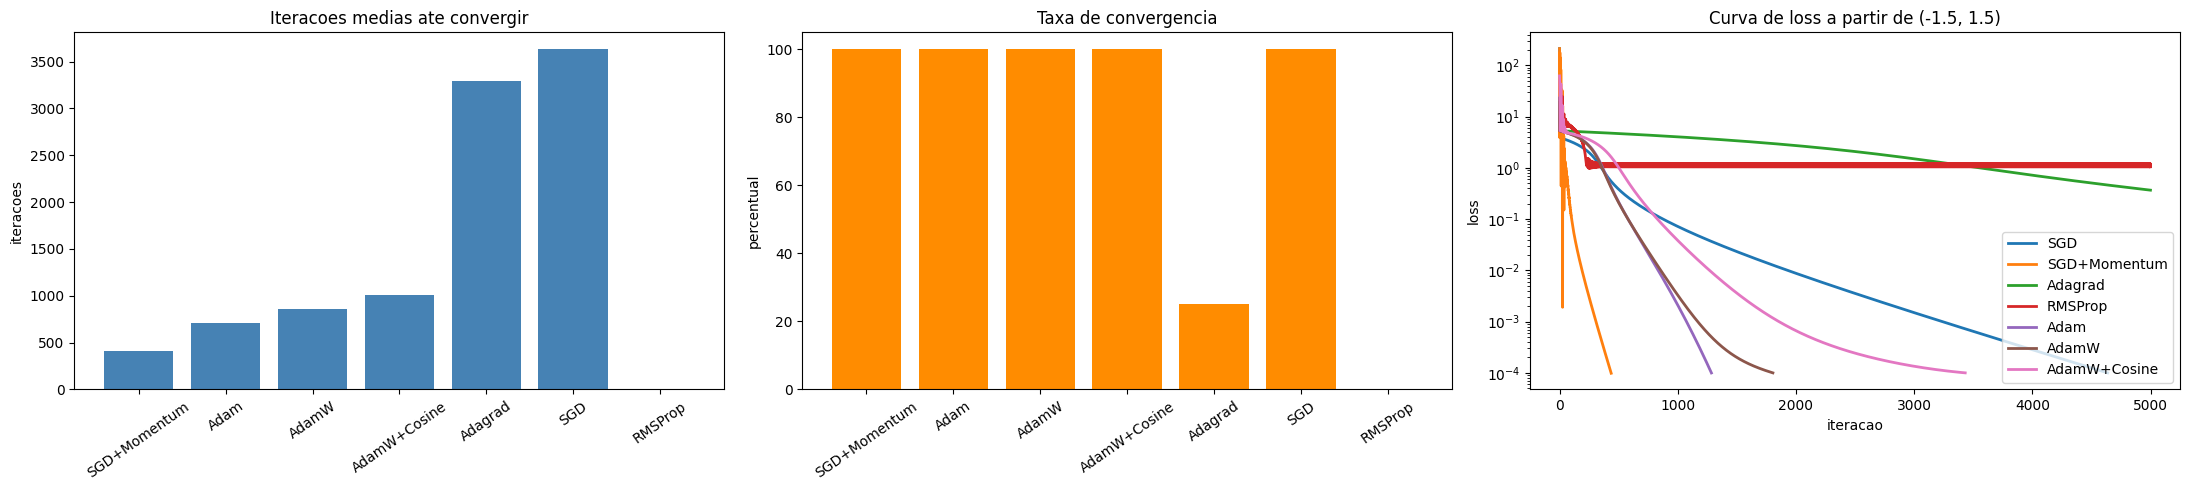

In [34]:
def plot_optimizer_performance(summary, results, reference_init=(-1.5, 1.5)):
    names = [row["optimizer"] for row in summary]
    mean_iterations = [
        row["mean_iterations"] if not np.isnan(row["mean_iterations"]) else 0
        for row in summary
    ]
    convergence_rates = [row["convergence_rate"] for row in summary]
    mean_final_losses = [row["mean_final_loss"] for row in summary]

    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    axes[0].bar(names, mean_iterations, color="steelblue")
    axes[0].set_title("Iteracoes medias ate convergir")
    axes[0].set_ylabel("iteracoes")
    axes[0].tick_params(axis="x", rotation=35)

    axes[1].bar(names, convergence_rates, color="darkorange")
    axes[1].set_title("Taxa de convergencia")
    axes[1].set_ylabel("percentual")
    axes[1].set_ylim(0, 105)
    axes[1].tick_params(axis="x", rotation=35)

    reference_runs = [row for row in results if row["init"] == reference_init]
    for row in reference_runs:
        y = np.maximum(np.array(row["history"], dtype=float), 1e-12)
        axes[2].plot(y, label=row["optimizer"], linewidth=2)

    axes[2].set_title(f"Curva de loss a partir de {reference_init}")
    axes[2].set_xlabel("iteracao")
    axes[2].set_ylabel("loss")
    axes[2].set_yscale("log")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

plot_optimizer_performance(summary, results)